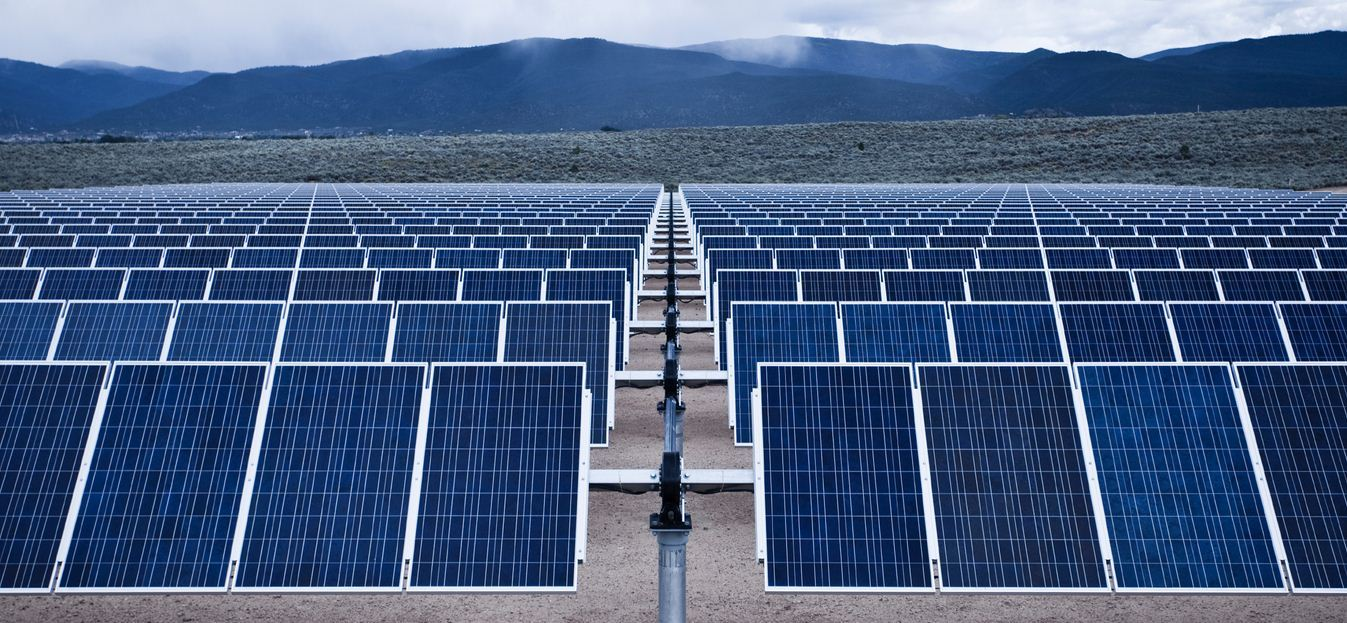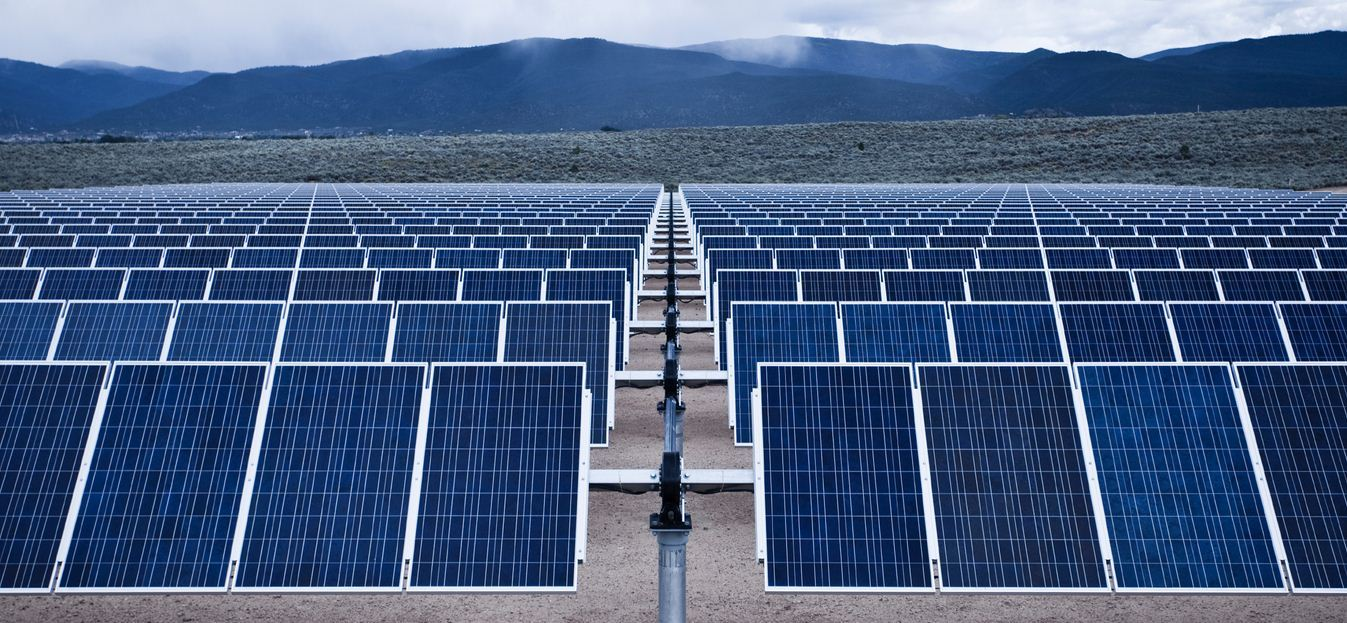


In [13]:
import numpy as np # To perform numerical operations
import pandas as pd # To do data manipulation and analysis
import matplotlib.pyplot as plt # For data visualization
import seaborn as sns # For advanced Data visualizations
from sklearn.preprocessing import StandardScaler # for feature scaling
from sklearn.model_selection import train_test_split # For splitting dataset into training and testing set
from sklearn.linear_model import LinearRegression # For Model Selection
from sklearn.ensemble import RandomForestRegressor # Model Selection for Random Forest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # To Evaluate Model's Performance
from datetime import datetime  # To handle time based features 
import joblib # For saving and Loading the Trained Model

In [14]:
#Loading the plant 1 generation and Weather Sensor Data
generation_data = pd.read_csv('Plant_1_Generation_Data.csv')
weather_data = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')

In [15]:
generation_data

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.000,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.000,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.000,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.000,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.000,7158964.0
...,...,...,...,...,...,...,...
68773,17-06-2020 23:45,4135001,uHbuxQJl8lW7ozc,0.0,0.0,5967.000,7287002.0
68774,17-06-2020 23:45,4135001,wCURE6d3bPkepu2,0.0,0.0,5147.625,7028601.0
68775,17-06-2020 23:45,4135001,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000,7251204.0
68776,17-06-2020 23:45,4135001,zBIq5rxdHJRwDNY,0.0,0.0,5817.000,6583369.0


In [16]:
# before merging the datasets we ne to convert date time format for proper time alignement

generation_data['DATE_TIME'] = pd.to_datetime(generation_data['DATE_TIME']) # Parsing the date string in the format of Day/month/year
weather_data['DATE_TIME'] = pd.to_datetime(weather_data['DATE_TIME'])
weather_data.head()

C:\Users\ARYAN\AppData\Local\Temp\ipykernel_35528\2888086797.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  generation_data['DATE_TIME'] = pd.to_datetime(generation_data['DATE_TIME']) # Parsing the date string in the format of Day/month/year
C:\Users\ARYAN\AppData\Local\Temp\ipykernel_35528\2888086797.py:4: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  weather_data['DATE_TIME'] = pd.to_datetime(weather_data['DATE_TIME'])


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [17]:
# Aggregating Generation Data
generation_agg = generation_data.groupby('DATE_TIME').agg({
    'DC_POWER':'sum', #calculating the sum of DC_Power
    'AC_POWER':'sum', #calculating the sum of AC_POWER
    'DAILY_YIELD' : 'mean', #calculating the average of DAILY_YEILD
    'TOTAL_YIELD' : 'mean' #calculating the average of TOTAL_YIELD
}).reset_index() # Used to control and manage the structure of a Dataframe's Index


In [18]:
generation_agg

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,0.0,0.0,0.000000,6.837223e+06
1,2020-05-15 00:15:00,0.0,0.0,0.000000,6.837223e+06
2,2020-05-15 00:30:00,0.0,0.0,0.000000,6.837223e+06
3,2020-05-15 00:45:00,0.0,0.0,0.000000,6.837223e+06
4,2020-05-15 01:00:00,0.0,0.0,0.000000,6.852802e+06
...,...,...,...,...,...
3153,2020-06-17 22:45:00,0.0,0.0,5889.590909,7.097398e+06
3154,2020-06-17 23:00:00,0.0,0.0,5889.590909,7.097398e+06
3155,2020-06-17 23:15:00,0.0,0.0,5889.590909,7.097398e+06
3156,2020-06-17 23:30:00,0.0,0.0,5889.590909,7.097398e+06


In [19]:
# aggregating Weather Sensor Data
weather_agg = weather_data.groupby('DATE_TIME').agg({
    'AMBIENT_TEMPERATURE' : 'mean', #calculating average AMBIENT_TEMPERATURE
    'MODULE_TEMPERATURE' : 'mean', #calculating average MODULE_TEMPERATURE
    'IRRADIATION' : 'mean' #calculating average IRRADIATION
}).reset_index()


In [20]:
Final_Data = pd.merge(generation_agg,weather_agg,on='DATE_TIME',how='inner') #how carries other values like outer, left and right

In [21]:
# Savind the Merged Dataset
Final_Data.to_csv('Plant1_Merged_Dataset.csv',index=False)


(array([1747.,  193.,  147.,  161.,  185.,  198.,  185.,  159.,  118.,
          64.]),
 array([     0.      ,  29893.778571,  59787.557142,  89681.335713,
        119575.114284, 149468.892855, 179362.671426, 209256.449997,
        239150.228568, 269044.007139, 298937.78571 ]),
 <BarContainer object of 10 artists>)

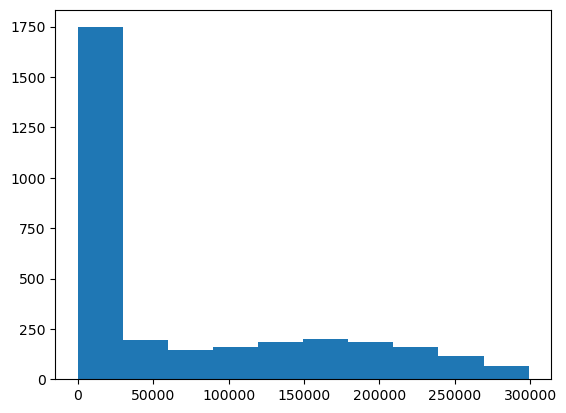

In [22]:
# exploring null values
Final_Data.isnull().sum()
plt.hist(Final_Data["DC_POWER"])

In [23]:
# exploring null values
Final_Data.isnull().sum()
daytime_data = Final_Data[Final_Data['IRRADIATION']>0] # filtering only the day time data by setting Irridation > 0
numeric_columns = daytime_data.select_dtypes(include=['float64', 'int64']).columns # selecting only numeric columns from the dataframe

In [24]:
sns.set(style="whitegrid")

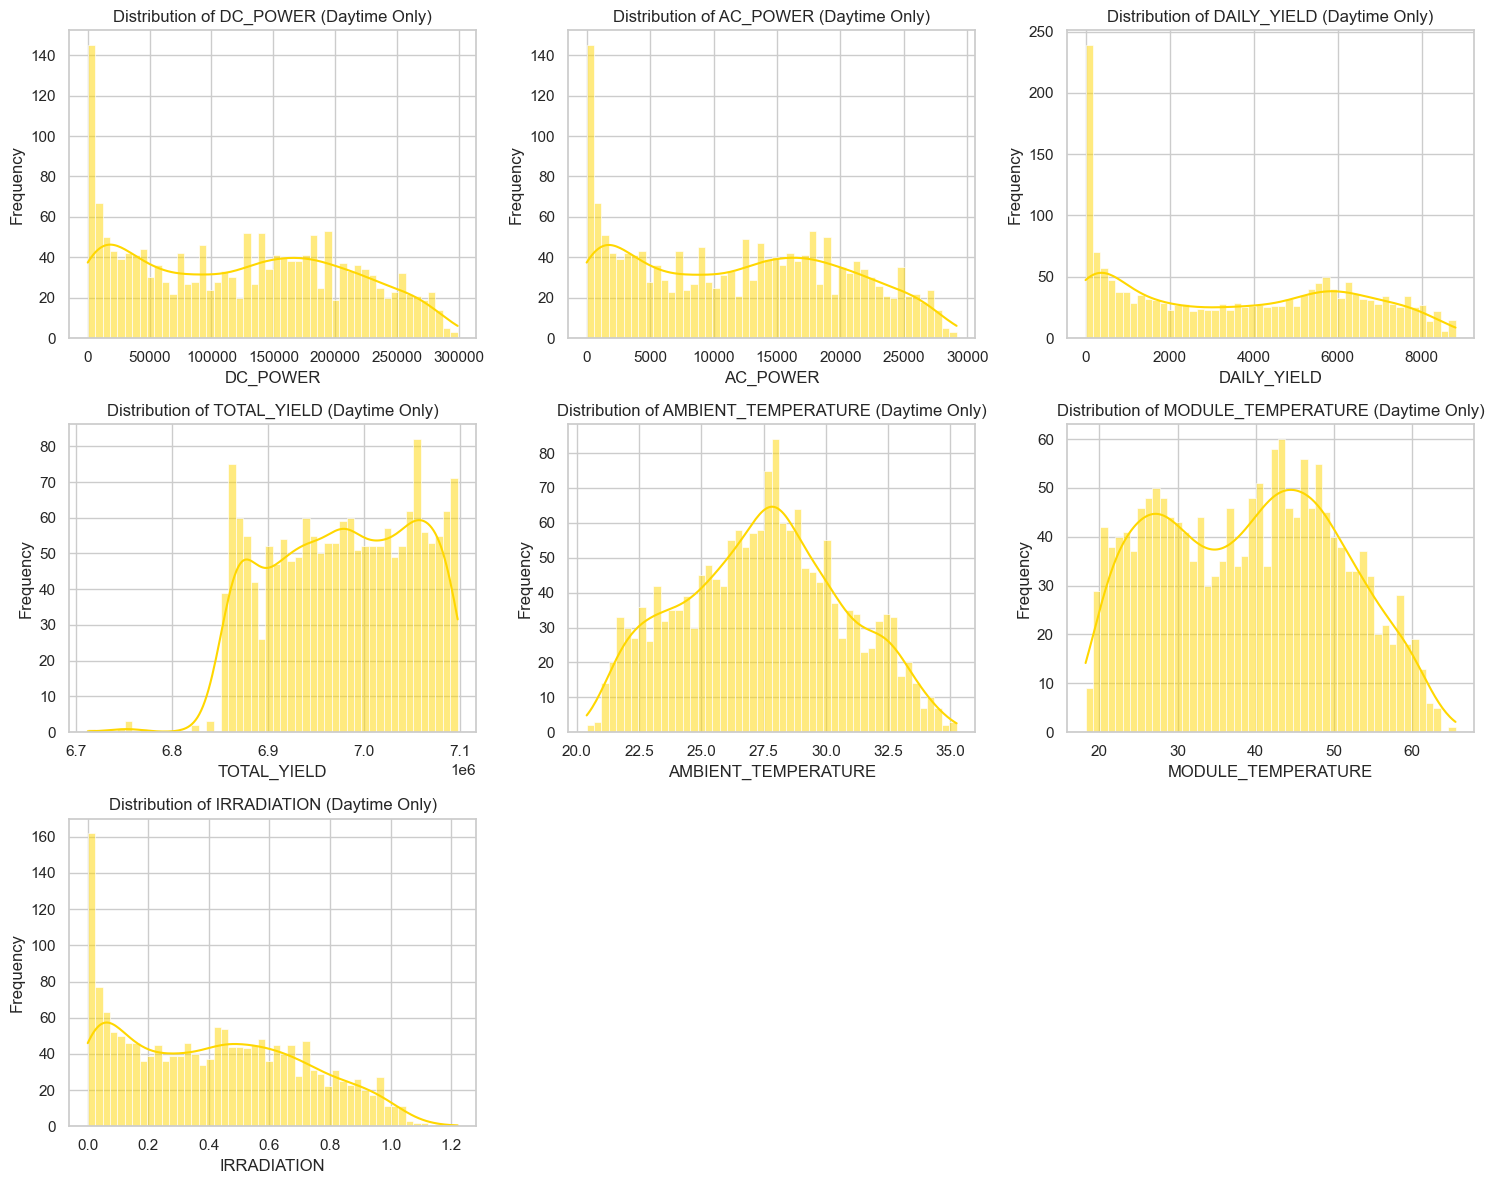

In [25]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_columns):
    plt.subplot(3, 3, i + 1)
    sns.histplot(daytime_data[col], kde=True, bins=50, color='gold')
    plt.title(f'Distribution of {col} (Daytime Only)')
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [26]:
## #**A short summary From the above Feature Distribution**
#* **DC_POWER & AC_POWER** : Both show right-skewed distributions, indicating most readings are at lower power levels with fewer high-output instances.
#* **DAILY_YEILD** : Right-skewed distribution suggests many days with lower energy production, potentially due to shorter daylight hours or cloudy weather conditions.
#* **TOTAL_YEILD** : Displays a narrow range with a nearly uniform spread.
#* **AMBIENT_TEMPERATURE** : Approximately normal distribution centered around 27–28°C.
#* **MODULE_TEMPERATURE** : Bimodal distribution shows distinct heating patterns
#* **IRRADIATION** : Strongly right-skewed, with a high frequency of low values.


In [27]:
# Set DATE_TIME as the index
Final_Data.set_index('DATE_TIME', inplace=True)
Final_Data.sort_index(inplace=True)


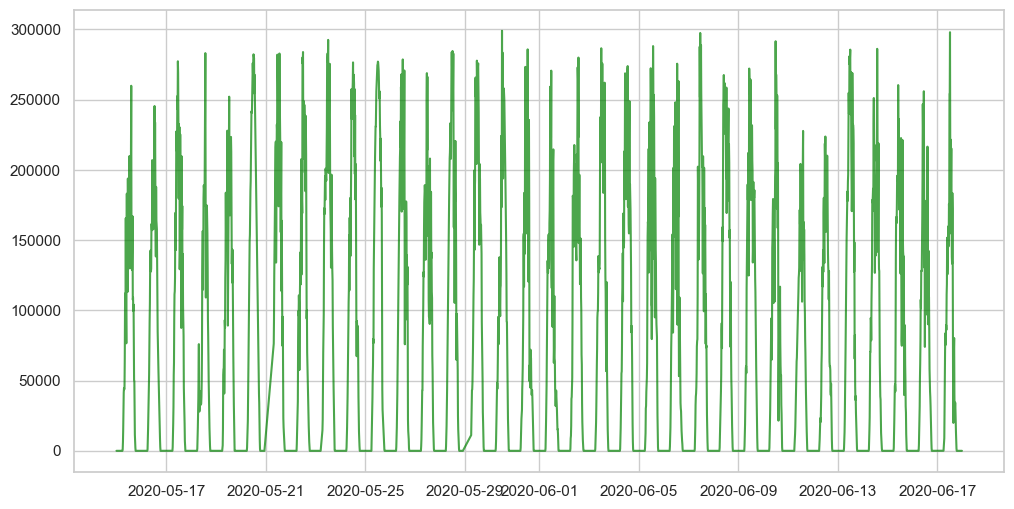

In [28]:
# Plot DC_POWER time series
plt.figure(figsize=(12, 6))
plt.plot(Final_Data.index, Final_Data['DC_POWER'], color="green", alpha=0.7, label="DC_POWER")


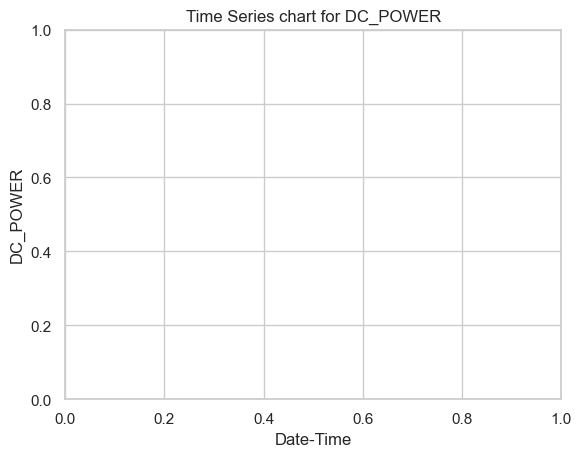

In [29]:
plt.title("Time Series chart for DC_POWER")
plt.xlabel("Date-Time")
plt.ylabel("DC_POWER")
#plt.legend()
plt.show()


In [30]:
correlation_matrix = Final_Data.corr(numeric_only = True) # calculating the pairwise correlation b/w all numerical columns
correlation_matrix


,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
DC_POWER,1.000000,0.999997,0.075897,-0.009787,0.725679,0.960939,0.995957
AC_POWER,0.999997,1.000000,0.075839,-0.009706,0.725879,0.961011,0.995864
DAILY_YIELD,0.075897,0.075839,1.000000,0.019176,0.491900,0.198208,0.073364
TOTAL_YIELD,-0.009787,-0.009706,0.019176,1.000000,-0.202452,-0.076345,-0.017062
AMBIENT_TEMPERATURE,0.725679,0.725879,0.491900,-0.202452,1.000000,0.853162,0.721839
MODULE_TEMPERATURE,0.960939,0.961011,0.198208,-0.076345,0.853162,1.000000,0.961422
IRRADIATION,0.995957,0.995864,0.073364,-0.017062,0.721839,0.961422,1.000000


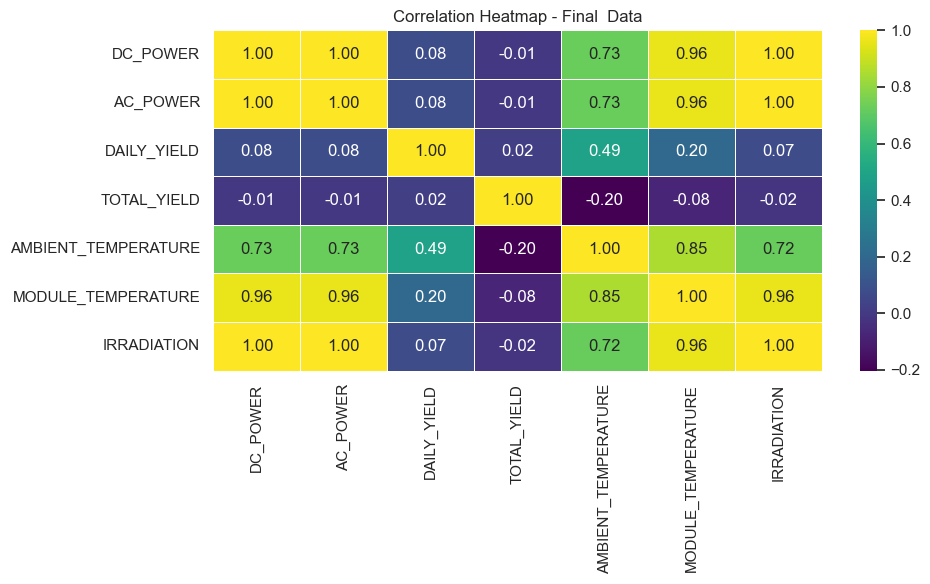

In [31]:
plt.figure(figsize=(10, 6)) # sets the figure size as 10 inches width and 6 inches tall
sns.heatmap(correlation_matrix, annot=True, cmap="viridis", fmt=".2f", linewidths=0.5) 
plt.title("Correlation Heatmap - Final  Data")
plt.tight_layout() # used to prevent the overlapping in the figure area
plt.show() # used to visualize the figure


In [32]:
#“From the above correlation heatmap we can clearly understand that the high correlations near 1+ shows that irradiation is the dominant factor
#driving power production and module temperature. The Moderate positive correlations around 0.5 to 0.8 shows more energy produced on sunny days based on the  AMBIENT_TEMPERATURE with DC_POWER / AC_POWER and DAILY_YIELD. The weak (0) or negative (-) values shows no correlation and it's not statistically meaningful.”


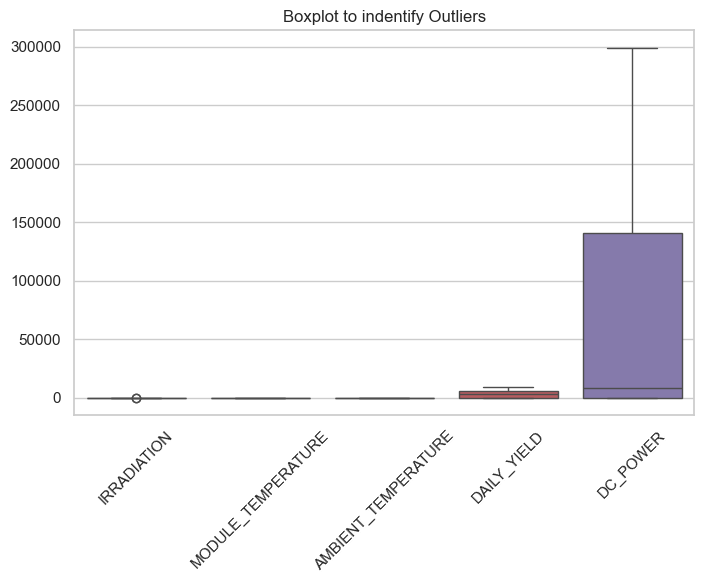

In [33]:
# Using these features to visualize the box plot to identify the outliers in a dataframe
Features = [
    'IRRADIATION',
    'MODULE_TEMPERATURE',
    'AMBIENT_TEMPERATURE',
    'DAILY_YIELD',
    'DC_POWER'
]
plt.figure(figsize=(8, 5))
sns.boxplot(data=Final_Data[Features])
plt.title("Boxplot to indentify Outliers")
plt.xticks(rotation=45)
plt.show()


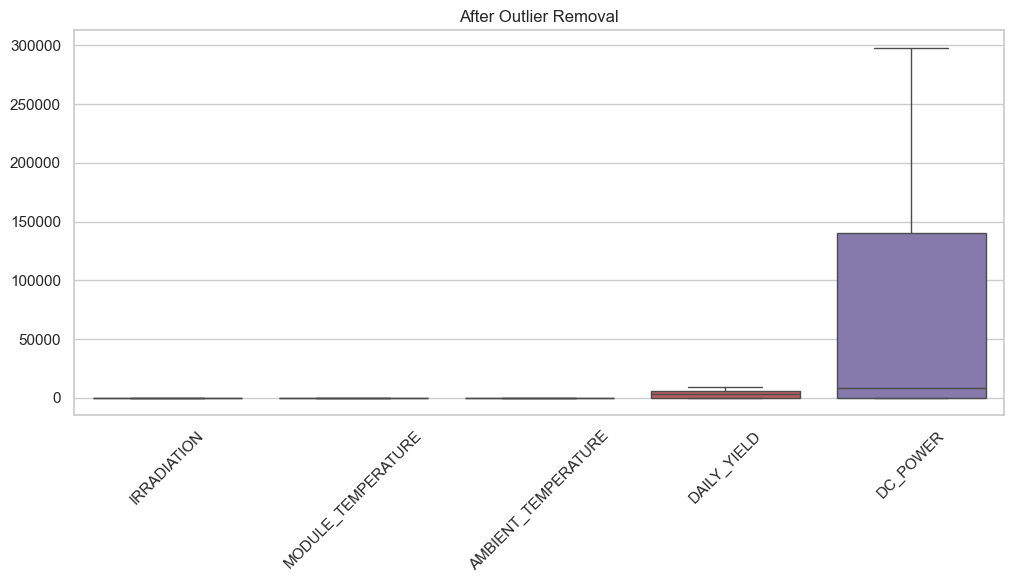

In [34]:
# creating a copy to avoid the changes in original data
Data_Clean = Final_Data.copy()


#applying IQR method to remove the outliers
for col in Features:
    Q1 = Data_Clean[col].quantile(0.25)
    Q3 = Data_Clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    Data_Clean = Data_Clean[(Data_Clean[col] >= lower_bound) & (Data_Clean[col] <= upper_bound)]


#Visualizing the box plot after removing the outliers
plt.figure(figsize=(12, 5))
sns.boxplot(data=Data_Clean[Features])
plt.title("After Outlier Removal")
plt.xticks(rotation=45)
plt.show()


In [35]:
features_to_scale = [
    'IRRADIATION',
    'MODULE_TEMPERATURE',
    'AMBIENT_TEMPERATURE',
    'DAILY_YIELD',
    'DC_POWER',
    'AC_POWER' 
]
scaler = StandardScaler()
Final_Data_standardized = Final_Data.copy()
Final_Data_standardized[features_to_scale] = scaler.fit_transform(Final_Data[features_to_scale])

print(Final_Data_standardized.head())

                     DC_POWER  AC_POWER  DAILY_YIELD   TOTAL_YIELD  \
DATE_TIME                                                            
2020-05-15 00:00:00  -0.77872 -0.779373    -1.091826  6.837223e+06   
2020-05-15 00:15:00  -0.77872 -0.779373    -1.091826  6.837223e+06   
2020-05-15 00:30:00  -0.77872 -0.779373    -1.091826  6.837223e+06   
2020-05-15 00:45:00  -0.77872 -0.779373    -1.091826  6.837223e+06   
2020-05-15 01:00:00  -0.77872 -0.779373    -1.091826  6.852802e+06   

                     AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION  
DATE_TIME                                                                  
2020-05-15 00:00:00            -0.112203           -0.677868    -0.763699  
2020-05-15 00:15:00            -0.141968           -0.685679    -0.763699  
2020-05-15 00:30:00            -0.186390           -0.699481    -0.763699  
2020-05-15 00:45:00            -0.213138           -0.718343    -0.763699  
2020-05-15 01:00:00            -0.280174           -0

In [36]:
features = ['IRRADIATION', 'MODULE_TEMPERATURE', 'AMBIENT_TEMPERATURE'] # Input features or Independant Features
target = 'DC_POWER' # Target Varibale or Dependent Variable

X = Final_Data_standardized[features]
y = Final_Data_standardized[target]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=40)

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [37]:
# Making predictions with the test data
y_pred = model.predict(X_test)
y_pred


mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R² Score:", r2)

MSE: 0.008098576821535999
R² Score: 0.9919313632745049


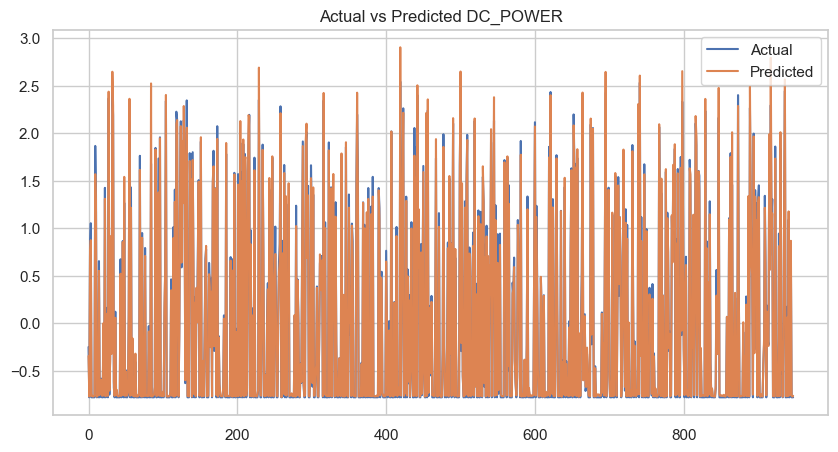

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.title("Actual vs Predicted DC_POWER")
plt.legend()
plt.show()


In [39]:
# features used in model training
features = ['IRRADIATION', 'MODULE_TEMPERATURE', 'AMBIENT_TEMPERATURE']

# user input
user_input = []
print("Enter values for the following features:")

for feature in features:
    value = float(input(f"{feature}: "))
    user_input.append(value)

# Reshape to match scaler input
input_array = np.array(user_input).reshape(1, -1)

# Scale using a new scaler trained only on those 3 features
scaler = StandardScaler().fit(X_train)  
scaled_input = scaler.transform(input_array)

# Predict
predicted_power = model.predict(scaled_input)

print(f"\n⚡ Predicted DC Power: {predicted_power[0]:.4f}")


Enter values for the following features:


IRRADIATION:  300
MODULE_TEMPERATURE:  22
AMBIENT_TEMPERATURE:  30



⚡ Predicted DC Power: 284.6908


C:\Users\ARYAN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ARYAN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
joblib.dump(model, 'solar_Power_eneration_model.pkl')